## Perform Data-Centric Modeling

In [1]:
import numpy as np
import pandas as pd
#%pip install yfinance
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
import requests
warnings.filterwarnings("ignore")


In [2]:
import os, subprocess

REPO_URL = "https://github.com/tongyuguo/HelpHerInvest.git"
REPO_DIR = "HelpHerInvest"
data_dir = os.path.join(REPO_DIR, "Data")

def clone_or_pull():
    if os.path.isdir(os.path.join(REPO_DIR, ".git")):
        subprocess.run(["git", "-C", REPO_DIR, "pull"])
    else:
        subprocess.run(["git", "clone", REPO_URL])

clone_or_pull()

From https://github.com/tongyuguo/HelpHerInvest
   cbdd04e..774b74f  main       -> origin/main


Updating cbdd04e..774b74f
Fast-forward
 Code Outputs/Week 08/week08_third_model.pdf        |  Bin 0 -> 60433 bytes
 .../Week 09/week09_developing_winning_model.pdf    |  Bin 0 -> 732942 bytes
 .../Week 09/week09_developing_winning_model.ipynb  | 9818 ++++++++++++++++++++
 .../week09_developing_winning_modell01.ipynb       | 9818 ++++++++++++++++++++
 .../week10_data_centric_modell01.ipynb             | 2464 +++++
 ...nvest_presentation_updated_weeks6_9 - new.ipynb |  379 +
 ...lpherinvest_presentation_updated_weeks6_9.ipynb |  350 +
 Reports/Week 09/filepath.html                      |    1 +
 .../week09_helpherinvest_written_report.pdf        |  Bin 0 -> 678641 bytes
 Reports/filepath.html                              |    1 +
 10 files changed, 22831 insertions(+)
 create mode 100644 Code Outputs/Week 08/week08_third_model.pdf
 create mode 100644 Code Outputs/Week 09/week09_developing_winning_model.pdf
 create mode 100644 Notebooks/Week 09/week09_developing_winning_model.ipynb
 creat

In [3]:
# Load the data from the zip file

## PATH NEEDS TO BE UPDATED TO GITHUB DATA PATH
zip_path2 = "HelpHerInvest/Data/final_dataset_20260224v2.csv.zip"
with zipfile.ZipFile(zip_path2) as z:
    df = pd.read_csv(z.open("final_dataset_20260224v2.csv"))

## ## ## ## 

tickers = df["Ticker"].unique()
print(f"Unique tickers in final dataset: {len(tickers)}")
print("Size of dataset:",
"Rows:",df.shape[0],
"Columns:",df.shape[1])

Unique tickers in final dataset: 1993
Size of dataset: Rows: 302024 Columns: 18


In [4]:
# count number of positive fwd_excess_return
print("Number of positive fwd_excess_return:", (df["fwd_excess"] > 0).sum())
print("Number of negative fwd_excess_return:", (df["fwd_excess"] < 0).sum())
print("Number of zero fwd_excess_return:", (df["fwd_excess"] == 0).sum())

df_temp = df.copy()

df_temp['y'] = (df_temp['fwd_excess'] > 0).astype(int)



Number of positive fwd_excess_return: 143948
Number of negative fwd_excess_return: 151730
Number of zero fwd_excess_return: 287


In [5]:
df = df_temp.dropna()
print("---  ---  ---")
print("Length of original:",len(df_temp.index))
print("Length of dropped:",len(df.index))

---  ---  ---
Length of original: 302024
Length of dropped: 274511


### Create Dataset 1 - Cross Sectionally Ranked

In [6]:
rank_cols = [
    'mom_1m','mom_3m','mom_6m','mom_12m','mom_12m_ex_1m',
    'rel_3m_spy','rel_6m_spy','rel_12m_spy',
    'vol_3m','vol_6m',
    'drawdown_6m','drawdown_12m',
    'pct_above_200dma'
]

df_rank = df.copy()

for col in rank_cols:
    df_rank[col] = df_rank.groupby("Date")[col].rank(pct=True)

#df_rank[rank_cols].head(10)

In [7]:
df_rank["fwd_rank"] = df_rank.groupby("Date")["fwd_excess"].rank(pct=True)

df_rank["target"] = pd.cut(
    df_rank["fwd_rank"],
    bins=[0, .2, .4, .6, .8, 1],
    labels=[0,1,2,3,4]
)

df_rank.head(10)

,Date,Ticker,mom_1m,mom_3m,mom_6m,mom_12m,mom_12m_ex_1m,rel_3m_spy,rel_6m_spy,rel_12m_spy,...,vol_6m,drawdown_6m,drawdown_12m,pct_above_200dma,adj_close,fwd_excess,fwd_return,y,fwd_rank,target
13389,2011-01-31,NVDA,0.997496,0.995826,0.995826,0.814691,0.137730,0.995826,0.995826,0.814691,...,0.928214,0.744157,0.790067,0.995826,0.5483,-0.2287,-0.1639,0,0.030050,0
13390,2011-01-31,GOOGL,0.480801,0.142738,0.636060,0.281302,0.276294,0.142738,0.636060,0.281302,...,0.438230,0.377295,0.476628,0.515025,14.9114,-0.1585,-0.0937,0,0.070117,0
13391,2011-01-31,AAPL,0.729549,0.623539,0.766277,0.909015,0.889816,0.623539,0.766277,0.909015,...,0.222871,0.744157,0.790067,0.747913,10.1670,-0.0330,0.0319,0,0.317195,1
13392,2011-01-31,MSFT,0.381469,0.343907,0.277963,0.121870,0.144407,0.343907,0.277963,0.121870,...,0.181135,0.450751,0.256260,0.288815,21.1071,-0.1246,-0.0597,0,0.101836,0
13393,2011-01-31,AMZN,0.152755,0.280467,0.883973,0.601836,0.727045,0.280467,0.883973,0.601836,...,0.666110,0.220367,0.330968,0.607679,8.4820,0.0894,0.1543,1,0.747913,3
13394,2011-01-31,AVGO,0.479967,0.727045,0.768781,0.868114,0.873957,0.727045,0.768781,0.868114,...,0.817195,0.744157,0.790067,0.839733,2.0278,0.1036,0.1685,1,0.787145,3
13396,2011-01-31,BRK-B,0.545910,0.282137,0.193656,0.191987,0.180301,0.282137,0.193656,0.191987,...,0.076795,0.426544,0.527546,0.192821,81.7500,-0.0459,0.0190,0,0.267947,1
13397,2011-01-31,LLY,0.373122,0.210351,0.120200,0.154424,0.184474,0.210351,0.120200,0.154424,...,0.035893,0.308848,0.414023,0.149833,24.0450,0.0144,0.0793,1,0.492487,2
13398,2011-01-31,WMT,0.665275,0.327212,0.330551,0.196160,0.166945,0.327212,0.330551,0.196160,...,0.010017,0.744157,0.790067,0.309683,13.7084,-0.0774,-0.0126,0,0.181970,0
13399,2011-01-31,JPM,0.760434,0.785476,0.361436,0.322204,0.227880,0.785476,0.361436,0.322204,...,0.493322,0.744157,0.790067,0.526711,29.9574,-0.0440,0.0209,0,0.276711,1


#### Create Dataset 2 - Skinny Dataset (6-Month Stats Only)

In [8]:
## Columns to use as features

df_skinny = df_temp.copy()

print(df_skinny.columns)

## Skinny Dataset - Only Using 6 Month Features
feature_cols = [col for col in df_skinny.columns if "6m" in col and
                col not in ["Ticker", "Date", "fwd_excess", "y"]]

#print("Features used for modeling:", feature_cols)

df_skinny = df_skinny[["Date", "Ticker", "fwd_excess", "y"] + feature_cols]
print("Skinny dataset shape:", df_skinny.shape)
print("Skinny dataset columns:", df_skinny.columns)



Index(['Date', 'Ticker', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m',
       'mom_12m_ex_1m', 'rel_3m_spy', 'rel_6m_spy', 'rel_12m_spy', 'vol_3m',
       'vol_6m', 'drawdown_6m', 'drawdown_12m', 'pct_above_200dma',
       'adj_close', 'fwd_excess', 'fwd_return', 'y'],
      dtype='object')
Skinny dataset shape: (302024, 8)
Skinny dataset columns: Index(['Date', 'Ticker', 'fwd_excess', 'y', 'mom_6m', 'rel_6m_spy', 'vol_6m',
       'drawdown_6m'],
      dtype='object')


### Create Dataset 3 - Add Featrues of Existing Data

In [9]:
df_feat = df_temp.copy()

# Create momentum spread features
df_feat["mom_spread_short_long"] = df["mom_3m"] - df["mom_12m"]
df_feat["mom_acceleration"] = df["mom_1m"] - df["mom_3m"]

# Volatility adjusted 
df_feat["vol_ratio"] = df["vol_3m"] / (df["vol_6m"] + 1e-6)
df_feat["mom_vol_adj"] = df["mom_3m"] / (df["vol_3m"] + 1e-6)

# Drawdown recovery signal
df_feat["recovery_signal"] = df["mom_1m"] / (abs(df["drawdown_6m"]) + 1e-6)

# Trend strength
df_feat["trend_strength"] = df["pct_above_200dma"] * df["mom_6m"]

In [10]:

def time_split(
    df,
    date_col="Date",
    train_frac=0.70,
    val_frac=0.15,
    test_frac=0.15,
    sort_dates=True
):
    if abs(train_frac + val_frac + test_frac - 1.0) > 1e-8:
        raise ValueError("train_frac + val_frac + test_frac must equal 1.0")

    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])

    if sort_dates:
        data = data.sort_values(date_col)

    unique_dates = pd.Series(data[date_col].drop_duplicates()).sort_values().reset_index(drop=True)

    n_dates = len(unique_dates)
    train_end = int(n_dates * train_frac)
    val_end = int(n_dates * (train_frac + val_frac))

    train_dates = unique_dates.iloc[:train_end]
    val_dates = unique_dates.iloc[train_end:val_end]
    test_dates = unique_dates.iloc[val_end:]

    train_df = data[data[date_col].isin(train_dates)].copy()
    val_df = data[data[date_col].isin(val_dates)].copy()
    test_df = data[data[date_col].isin(test_dates)].copy()

    return train_df, val_df, test_df



### Preprocess the Data 

In [11]:
def preprocess_data(df):

    # preprocess the data by dropping rows with missing values
    print("Missing fwd_excess values:")

    df_dropped = df.dropna()
    print("---  ---  ---")
    print("Length of original:",len(df.index))
    print("Length of dropped:",len(df_dropped.index))
    print("Sanity check - missing fwd_excess values after dropping:")
    print(df_dropped[["Date","Ticker","fwd_excess"]].tail(5)) 

   
    
    # Create log_adj_close column
    df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
    df_dropped[["adj_close","log_adj_close"]].hist(figsize=(14, 10), bins=50)
    plt.tight_layout()
    plt.show()
    
    return df_dropped

In [12]:
def retrieve_features(df):
    feature_cols = [col for col in df.columns if col not in ["Date", "Ticker", "fwd_excess", "fwd_return", "y","fwd_rank","target"]]
    return feature_cols

In [13]:
# Dataset 1 - Using Ranked Features

train_df_rank, val_df_rank, test_df_rank = time_split(df_rank, date_col="Date", train_frac=0.70, val_frac=0.15, test_frac=0.15)
X_train_rank = train_df_rank[retrieve_features(train_df_rank)]
y_train_rank = train_df_rank["y"]
X_val_rank = val_df_rank[retrieve_features(val_df_rank)]
y_val_rank = val_df_rank["y"]
X_test_rank = test_df_rank[retrieve_features(test_df_rank)]
y_test_rank = test_df_rank["y"]



In [14]:
# Dataset 2 - Using Skinny Features

train_df_skinny, val_df_skinny, test_df_skinny = time_split(df_skinny, date_col="Date", train_frac=0.70, val_frac=0.15, test_frac=0.15)
X_train_skinny = train_df_skinny[retrieve_features(train_df_skinny)]
y_train_skinny = train_df_skinny["y"]
X_val_skinny = val_df_skinny[retrieve_features(val_df_skinny)]
y_val_skinny = val_df_skinny["y"]
X_test_skinny = test_df_skinny[retrieve_features(test_df_skinny)]
y_test_skinny = test_df_skinny["y"]


In [15]:
# Dataset 3 - Using Engineered Features

train_df_feat, val_df_feat, test_df_feat = time_split(df_feat, date_col="Date", train_frac=0.70, val_frac=0.15, test_frac=0.15)
X_train_feat = train_df_feat[retrieve_features(train_df_feat)]
y_train_feat = train_df_feat["y"]
X_val_feat = val_df_feat[retrieve_features(val_df_feat)]
y_val_feat = val_df_feat["y"]
X_test_feat = test_df_feat[retrieve_features(test_df_feat)]
y_test_feat = test_df_feat["y"]

### Light Gradient Boosting Machine (LightGBM) Models

In [16]:
# Winning LightGBM Model - Dataset 1

import lightgbm as lgb

lgb_model1 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=12,
    num_leaves=31,
    class_weight="balanced",    
)

lgb_model1.fit(
    X_train_rank,
    y_train_rank,
    eval_set=[(X_val_rank, y_val_rank)],

)

[LightGBM] [Info] Number of positive: 86755, number of negative: 89946
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.067607 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3570
[LightGBM] [Info] Number of data points in the train set: 176701, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,12
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [17]:
# Winning LightGBM Model - Dataset 2

import lightgbm as lgb

lgb_model2 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=12,
    num_leaves=31,
    class_weight="balanced",    
)

lgb_model2.fit(
    X_train_skinny,
    y_train_skinny,
    eval_set=[(X_val_skinny, y_val_skinny)],

)

[LightGBM] [Info] Number of positive: 95899, number of negative: 97739
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 193638, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,12
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [18]:
# Winning LightGBM Model - Dataset 3

import lightgbm as lgb

lgb_model3 = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=12,
    num_leaves=31,
    class_weight="balanced",    
)

lgb_model3.fit(
    X_train_feat,
    y_train_feat,
    eval_set=[(X_val_feat, y_val_feat)],

)

[LightGBM] [Info] Number of positive: 95899, number of negative: 97739
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.047883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 193638, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,12
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score


## Used to Evaluate the Logistic Regression and LightGBM models ##
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print("Classification Report:\n")
    print(classification_report(y_test, y_pred))
    print("F1:", round(f1_score(y_test, y_pred, average='macro'), 4))
    print("ROC-AUC:", round(roc_auc_score(y_test, probs, average='macro'), 4))


print("LightGBM Model 1:")
evaluate(lgb_model1, X_val_rank, y_val_rank)
print("------------  --------------  ------------  --------------")
print("LightGBM Model 2:")
evaluate(lgb_model2, X_val_skinny, y_val_skinny)
print("------------  --------------  ------------  --------------")
print("LightGBM Model 3:")
evaluate(lgb_model3, X_val_feat, y_val_feat)


LightGBM Model 1:
Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.53      0.53     24830
           1       0.50      0.51      0.50     22658

    accuracy                           0.52     47488
   macro avg       0.52      0.52      0.52     47488
weighted avg       0.52      0.52      0.52     47488

F1: 0.5175
ROC-AUC: 0.5234
------------  --------------  ------------  --------------
LightGBM Model 2:
Classification Report:

              precision    recall  f1-score   support

           0       0.53      0.49      0.51     27877
           1       0.47      0.51      0.49     24827

    accuracy                           0.50     52704
   macro avg       0.50      0.50      0.50     52704
weighted avg       0.50      0.50      0.50     52704

F1: 0.4991
ROC-AUC: 0.5007
------------  --------------  ------------  --------------
LightGBM Model 3:
Classification Report:

              precision    recall  f1-score   su


Cross Sectional Ranked
          Pred 0  Pred 1
Actual 0   13127   11703
Actual 1   11180   11478


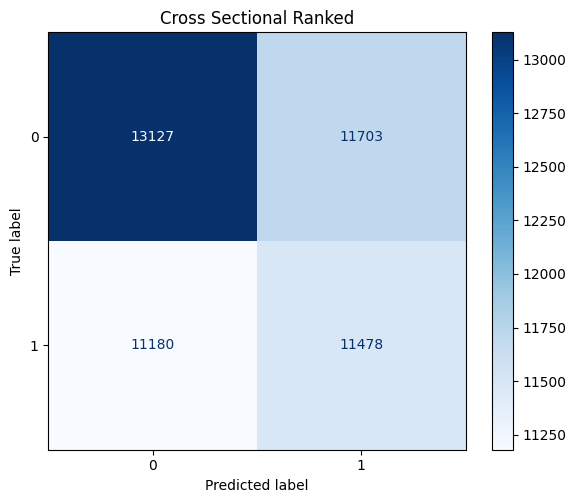


Skinny Features
          Pred 0  Pred 1
Actual 0   13739   14138
Actual 1   12247   12580


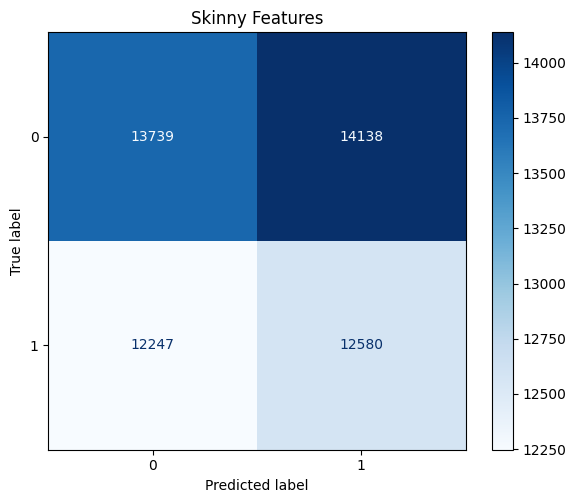


Engineered Features
          Pred 0  Pred 1
Actual 0   15753   12124
Actual 1   13562   11265


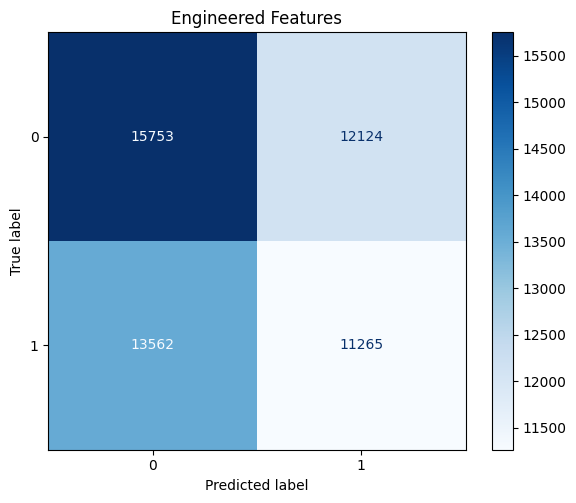

,Pred 0,Pred 1
Actual 0,15753,12124
Actual 1,13562,11265


In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def create_confusion_matrix(model, X_val, y_val, name):
    y_pred = model.predict(X_val)

    cm = confusion_matrix(y_val, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0", "Actual 1"],
        columns=["Pred 0", "Pred 1"]
    )

    print(f"\n{name}")
    print(cm_df)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]).plot(
        ax=ax,
        cmap="Blues",
        values_format="d"
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

    return cm_df


create_confusion_matrix(lgb_model1, X_val_rank, y_val_rank, "Cross Sectional Ranked")
create_confusion_matrix(lgb_model2, X_val_skinny, y_val_skinny, "Skinny Features")
create_confusion_matrix(lgb_model3, X_val_feat, y_val_feat, "Engineered Features")


In [21]:
# Selected the best model from validation performance and evaluate on test set
print("\n-----  -----  -----  -----  -----  -----  -----  -----  -----  -----")
print("LightGBM Model 1 - Test Set:")
evaluate(lgb_model1, X_test_rank, y_test_rank)


-----  -----  -----  -----  -----  -----  -----  -----  -----  -----
LightGBM Model 1 - Test Set:
Classification Report:

              precision    recall  f1-score   support

           0       0.54      0.52      0.53     26761
           1       0.48      0.49      0.49     23561

    accuracy                           0.51     50322
   macro avg       0.51      0.51      0.51     50322
weighted avg       0.51      0.51      0.51     50322

F1: 0.5087
ROC-AUC: 0.5126
